## Plan of Action


1.   Load **IMDb Movie Reviews dataset (50,000 reviews)**
2.   **Pre-process dataset** by removing special characters, numbers, etc. from user reviews + convert **sentiment labels** positive & negative to numbers 1 & 0, respectively
3.   **Import GloVe Word Embedding** to build Embedding Dictionary + Use this to build Embedding Matrix for our Corpus
4. Model Training using **Deep Learning in Keras** for separate: **Simple Neural Net, CNN and LSTM Models** and analyse model performance and results
4. Last, perform **predictions on real IMDb movie reviews**

## Setting the environment

## Loading dataset

In [ ]:
# Importing IMDb Movie Reviews dataset
import pandas as pd

movie_reviews = pd.read_csv("a1_IMDB_Dataset.csv")

# dataset source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [ ]:
# Dataset exploration

movie_reviews.shape

(50000, 2)

In [ ]:
movie_reviews.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Checking for missing values

movie_reviews.isnull().values.any()

np.False_

<Axes: xlabel='sentiment', ylabel='count'>

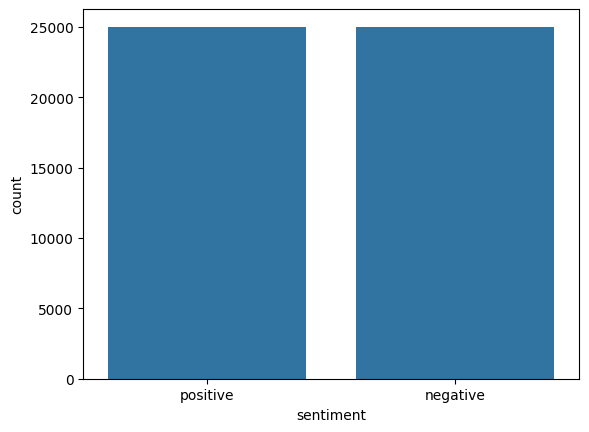

In [ ]:
# Let's observe distribution of positive / negative sentiments in dataset

import seaborn as sns
sns.countplot(x='sentiment', data=movie_reviews)

Let's examine the length of reviews before preprocessing.

In [ ]:
review_lengths = movie_reviews['review'].apply(len)
print(f"Minimum review length: {review_lengths.min()} characters")
print(f"Maximum review length: {review_lengths.max()} characters")
print(f"Average review length: {review_lengths.mean():.2f} characters")


Minimum review length: 32 characters
Maximum review length: 13704 characters
Average review length: 1309.43 characters


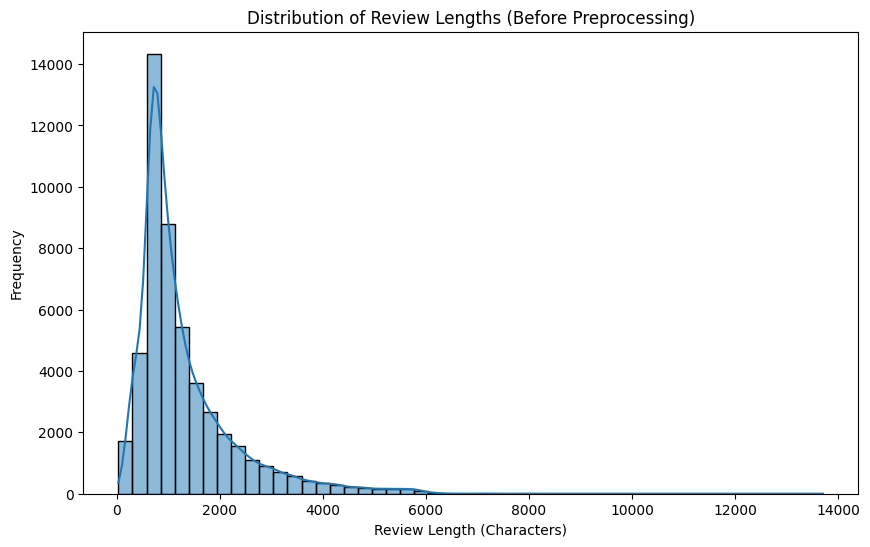

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(review_lengths, bins=50, kde=True)
plt.title('Distribution of Review Lengths (Before Preprocessing)')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Frequency')
plt.show()


Let's also look at a few raw reviews to get a sense of their content before cleaning.

In [ ]:
print("Example Positive Review:")
print(movie_reviews[movie_reviews['sentiment'] == 'positive']['review'].iloc[0][:500], "...")
print("\nExample Negative Review:")
print(movie_reviews[movie_reviews['sentiment'] == 'negative']['review'].iloc[0][:500], "...")


Example Positive Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ ...

Example Negative Review:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. An

## Data Preprocessing

In [ ]:
!pip install nltk

In [ ]:

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Activation, Dropout, Dense, Flatten,
    GlobalMaxPooling1D, Embedding, Conv1D, LSTM
)

from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
movie_reviews = pd.read_csv("a1_IMDB_Dataset.csv")

# dataset source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [ ]:
movie_reviews["review"][2]

# You can see that our text contains punctuations, brackets, HTML tags and numbers
# We will preprocess this text in the next section

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [ ]:
!pip install regex
import regex as re


In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''Removes HTML tags: replaces anything between opening and closing <> with empty space'''

    return TAG_RE.sub('', text)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS_LIST = stopwords.words('english')

def preprocess_text(sen):
    '''Cleans text data up, leaving only 2 or more char long non-stepwords composed of A-Z & a-z only
    in lowercase'''

    sentence = sen.lower()

    # Remove html tags
    sentence = remove_tags(sentence)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Mark's", the apostrophe is replaced by an empty space. Hence, we are left with single character "s" that we are removing here.

    # Remove multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)  # Next, we remove all the single characters and replace it by a space which creates multiple spaces in our text. Finally, we remove the multiple spaces from our text as well.

    # Remove Stopwords
    pattern = re.compile(r'\b(' + r'|'.join(STOPWORDS_LIST) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Calling preprocessing_text function on movie_reviews

X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [ ]:
# Find the maximum length of sentences in the preprocessed data
max_sentence_length = max(len(sen.split()) for sen in X)
print(f"Maximum sentence length in the dataset: {max_sentence_length} words")

Maximum sentence length in the dataset: 1401 words


In [ ]:
# Count the number of sentences exceeding 100 words
count_exceeding_100_words = sum(1 for sen in X if len(sen.split()) > 100)
print(f"Number of sentences exceeding 100 words: {count_exceeding_100_words}")

Number of sentences exceeding 100 words: 20812


In [ ]:
# Sample cleaned up movie review

X[2]

# As we shall use Word Embeddings, stemming/lemmatization is not performed as a preprocessing step here

'thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty characters likable even well bread suspected serial killer may disappointed realize match point risk addiction thought proof woody allen still fully control style many us grown love laughed one woody comedies years dare say decade never impressed scarlet johanson managed tone sexy image jumped right average spirited young woman may crown jewel career wittier devil wears prada interesting superman great comedy go see friends '

In [ ]:
# Converting sentiment labels to 0 & 1

y = movie_reviews['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# The train set will be used to train our deep learning models
# while test set will be used to evaluate how well our model performs

## Preparing embedding layer

Let's now write the script for our embedding layer. Embedding layer converts our textual data into numeric form. It is then **used as the first layer for the deep learning models in Keras**.

In [ ]:
# Embedding layer expects the words to be in numeric form
# Using Tokenizer function from keras.preprocessing.text library
# Method fit_on_text trains the tokenizer
# Method texts_to_sequences converts sentences to their numeric form
from tensorflow.keras.preprocessing.text import Tokenizer

word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

X_train = word_tokenizer.texts_to_sequences(X_train)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [ ]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist

vocab_length = len(word_tokenizer.word_index) + 1

vocab_length

92394

In [ ]:
average_sentence_length_words = sum(len(sen.split()) for sen in X) / len(X)
print(f"Average sentence length (in words) after preprocessing: {average_sentence_length_words:.2f} words")

Average sentence length (in words) after preprocessing: 117.89 words


In [ ]:
# Padding all reviews to fixed length 100
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Increasing maxlen and switching to 'pre' padding to improve LSTM memory
maxlen = 200

X_train_lstm = pad_sequences(word_tokenizer.texts_to_sequences(X_train_raw if 'X_train_raw' in locals() else X[:40000]), padding='post', maxlen=maxlen)
X_test_lstm = pad_sequences(word_tokenizer.texts_to_sequences(X_test_raw if 'X_test_raw' in locals() else X[40000:]), padding='post', maxlen=maxlen)

print(f"New sequence shape: {X_train_lstm.shape}")

New sequence shape: (40000, 200)


In [ ]:
# Load GloVe word embeddings and create an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('a2_glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [ ]:
# Create Embedding Matrix having 100 columns
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    # Check if embedding_vector is not None and has the expected dimension
    if embedding_vector is not None and len(embedding_vector) == 100:
        embedding_matrix[index] = embedding_vector
    elif embedding_vector is not None and len(embedding_vector) != 100:
        print(f"Warning: Skipping word '{word}' due to incorrect embedding dimension ({len(embedding_vector)} instead of 100).")
    # If embedding_vector is None, it means the word is not in the GloVe dictionary
    # In this case, the row in embedding_matrix remains zeros, which is appropriate.


In [ ]:
embedding_matrix.shape

(92394, 100)

# Model Training with:

## Simple Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

# Ensure vocab_length is defined from the tokenizer
vocab_length = len(word_tokenizer.word_index) + 1

snn_model = Sequential()

snn_model.add(
    Embedding(vocab_length, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False)
)

snn_model.add(Flatten())
snn_model.add(Dropout(0.5))
snn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Model compiling

snn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(snn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
# Model training

snn_model_history = snn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.6700 - loss: 0.6173 - val_acc: 0.7452 - val_loss: 0.5261
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7409 - loss: 0.5330 - val_acc: 0.7586 - val_loss: 0.5040
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7483 - loss: 0.5243 - val_acc: 0.7592 - val_loss: 0.5057
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7547 - loss: 0.5155 - val_acc: 0.7596 - val_loss: 0.5044
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7533 - loss: 0.5149 - val_acc: 0.7574 - val_loss: 0.5168
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7593 - loss: 0.5083 - val_acc: 0.7598 - val_loss: 0.5034


In [ ]:
# Predictions on the Test Set

score = snn_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7514 - loss: 0.5212


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.5211528539657593
Test Accuracy: 0.7513999938964844


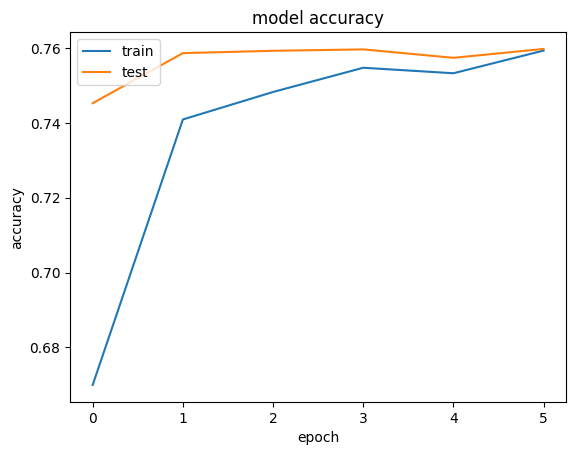

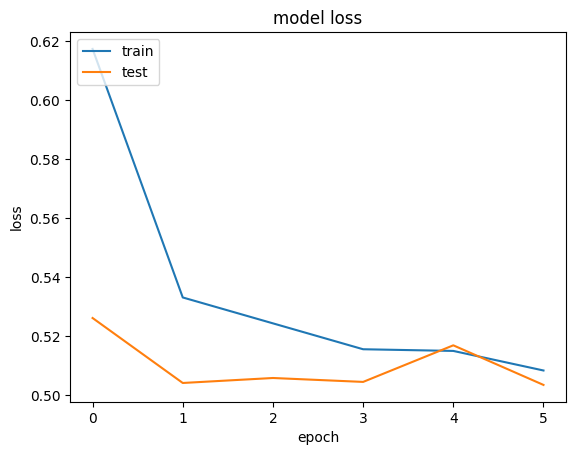

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(snn_model_history.history['acc'])
plt.plot(snn_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(snn_model_history.history['loss'])
plt.plot(snn_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
snn_model.save(f"./ann_simple{round(score[1], 3)}.h5", save_format='h5')

## Convolutional Neural Network

In [ ]:
from keras.layers import Conv1D

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout

cnn_model = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model.add(embedding_layer)
cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(Flatten())

cnn_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Model compiling

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
# Model training

cnn_model_history = cnn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.7464 - loss: 0.5120 - val_acc: 0.7945 - val_loss: 0.4574
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8273 - loss: 0.3934 - val_acc: 0.8175 - val_loss: 0.4173
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8689 - loss: 0.3200 - val_acc: 0.8248 - val_loss: 0.4002
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9137 - loss: 0.2340 - val_acc: 0.8184 - val_loss: 0.4181
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9475 - loss: 0.1637 - val_acc: 0.8159 - val_loss: 0.4447
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9699 - loss: 0.1131 - val_acc: 0.8150 - val_loss: 0.4826


In [ ]:
# Predictions on the Test Set

score = cnn_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8065 - loss: 0.5009


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.5008751749992371
Test Accuracy: 0.8065000176429749


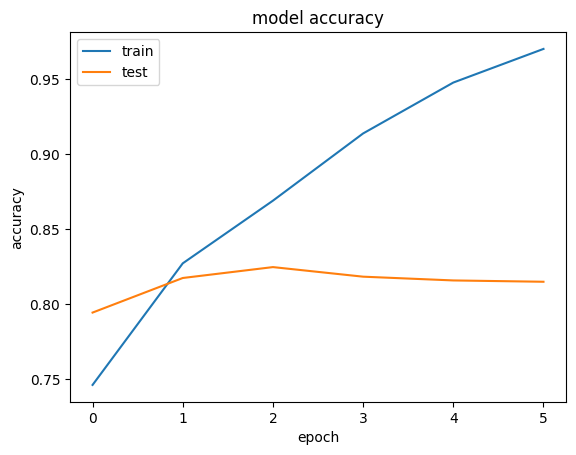

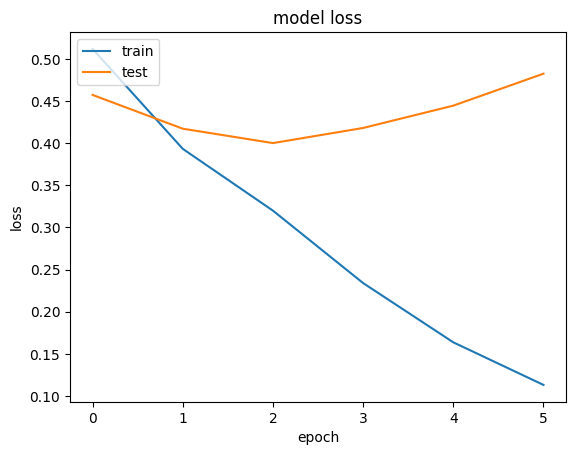

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(cnn_model_history.history['acc'])
plt.plot(cnn_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(cnn_model_history.history['loss'])
plt.plot(cnn_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout

cnn_model = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model.add(embedding_layer)
cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(Flatten())

cnn_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Saving the CNN model as an h5 file
cnn_model.save(f"./c1_cnn_model_acc_flatten()_{round(score[1], 3)}.h5", save_format='h5')

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout

cnn_model_drp = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model_drp.add(embedding_layer)
cnn_model_drp.add(Conv1D(128, 5, activation='relu'))
cnn_model_drp.add(Flatten())

cnn_model_drp.add(Dropout(0.3))
cnn_model_drp.add(Dense(1, activation='sigmoid'))

In [ ]:
cnn_model_drp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model_drp.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
# Model training

cnn_model_history_drp = cnn_model_drp.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.7362 - loss: 0.5236 - val_acc: 0.8067 - val_loss: 0.4344
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8158 - loss: 0.4102 - val_acc: 0.8195 - val_loss: 0.4080
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8516 - loss: 0.3464 - val_acc: 0.8316 - val_loss: 0.3893
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8818 - loss: 0.2904 - val_acc: 0.8183 - val_loss: 0.4264
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9066 - loss: 0.2374 - val_acc: 0.8274 - val_loss: 0.4053
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9234 - loss: 0.1976 - val_acc: 0.8073 - val_loss: 0.4869


In [ ]:

score = cnn_model_drp.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score[0])

print("Test Accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7966 - loss: 0.4875
Test Score: 0.4874970316886902
Test Accuracy: 0.7965999841690063


In [ ]:
cnn_model_drp.save(f"./c1_cnn_model_acc_flatten()_droput.3{round(score[1], 3)}.h5", save_format='h5')

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the new CNN model with learning rate scheduling
cnn_model_lr_scheduled = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model_lr_scheduled.add(embedding_layer)
cnn_model_lr_scheduled.add(Conv1D(128, 5, activation='relu'))
cnn_model_lr_scheduled.add(Flatten())

cnn_model_lr_scheduled.add(Dropout(0.3))
cnn_model_lr_scheduled.add(Dense(1, activation='sigmoid'))

# Compile the model
cnn_model_lr_scheduled.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(cnn_model_lr_scheduled.summary())

# Define callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

# Train the new model with callbacks
cnn_model_history_lr_scheduled = cnn_model_lr_scheduled.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler]
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.7398 - loss: 0.5179 - val_acc: 0.8029 - val_loss: 0.4367 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8210 - loss: 0.4063 - val_acc: 0.8167 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8521 - loss: 0.3479 - val_acc: 0.8256 - val_loss: 0.3927 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8760 - loss: 0.2993 - val_acc: 0.8259 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9154 - loss: 0.2255 - val_acc: 0.8261 - val_loss: 0.4027 - learning_rate: 5.0000e-04
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9319 - loss: 0.1936 - val_acc: 0.8263 - val_loss: 0.4061 - learning_rate: 2.5000e-04


In [ ]:

score = cnn_model_lr_scheduled.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score[0])

print("Test Accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8196 - loss: 0.4116
Test Score: 0.411648690700531
Test Accuracy: 0.819599986076355


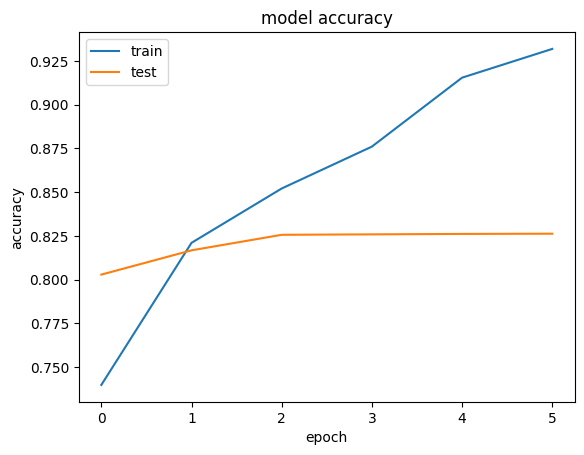

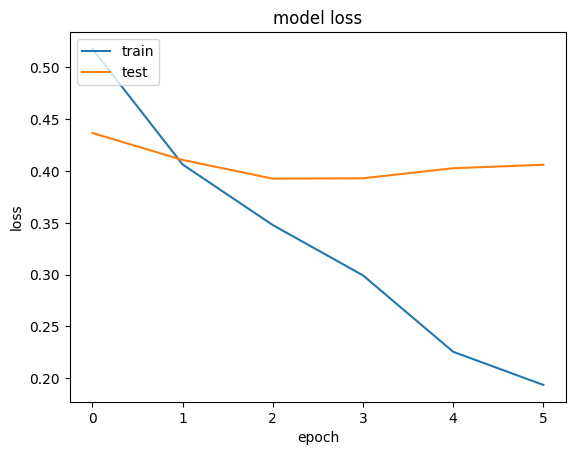

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(cnn_model_history_lr_scheduled.history['acc'])
plt.plot(cnn_model_history_lr_scheduled.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(cnn_model_history_lr_scheduled.history['loss'])
plt.plot(cnn_model_history_lr_scheduled.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout

cnn_model_glo = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model_glo.add(embedding_layer)
cnn_model_glo.add(Conv1D(128, 5, activation='relu'))
cnn_model_glo.add(GlobalMaxPooling1D())
cnn_model_glo.add(Dropout(0.3))
cnn_model_glo.add(Dense(1, activation='sigmoid'))
cnn_model_glo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model_glo.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
cnn_model_history_glo = cnn_model_glo.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.7247 - loss: 0.5353 - val_acc: 0.8136 - val_loss: 0.4142
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8187 - loss: 0.4009 - val_acc: 0.8270 - val_loss: 0.3826
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8443 - loss: 0.3561 - val_acc: 0.8393 - val_loss: 0.3623
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8609 - loss: 0.3241 - val_acc: 0.8462 - val_loss: 0.3507
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8745 - loss: 0.2958 - val_acc: 0.8447 - val_loss: 0.3498
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8854 - loss: 0.2739 - val_acc: 0.8440 - val_loss: 0.3513


In [ ]:
score = cnn_model_glo.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score[0])

print("Test Accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8502 - loss: 0.3463
Test Score: 0.34633317589759827
Test Accuracy: 0.8501999974250793


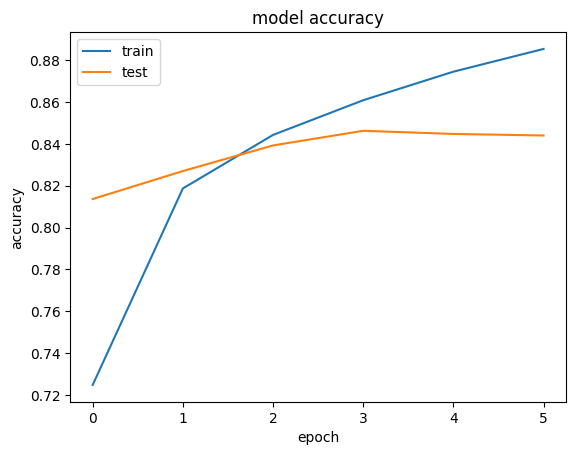

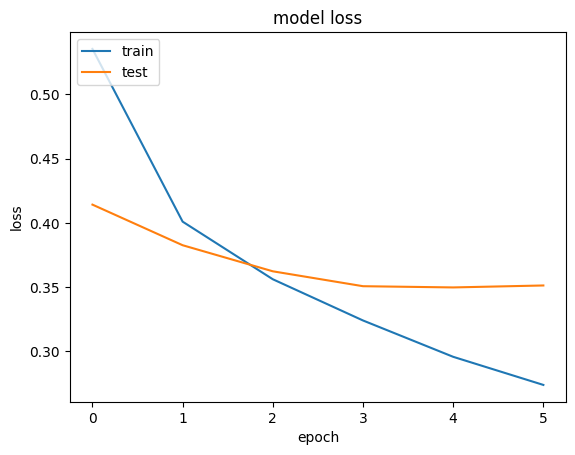

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(cnn_model_history_glo.history['acc'])
plt.plot(cnn_model_history_glo.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(cnn_model_history_glo.history['loss'])
plt.plot(cnn_model_history_glo.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling1D, Dropout

cnn_model_glo_es = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix] , trainable=False)
cnn_model_glo_es.add(embedding_layer)
cnn_model_glo_es.add(Conv1D(128, 5, activation='relu'))
cnn_model_glo_es.add(GlobalMaxPooling1D())
cnn_model_glo_es.add(Dropout(0.3))
cnn_model_glo_es.add(Dense(1, activation='sigmoid'))
cnn_model_glo_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model_glo_es.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
score = cnn_model_glo_es.evaluate(X_test, y_test, verbose=1)
print("Test Score:", score[0])

print("Test Accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4947 - loss: 0.7553
Test Score: 0.7553115487098694
Test Accuracy: 0.49470001459121704


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
cnn_model_history_glo_es = cnn_model_glo_es.fit(X_train, y_train, batch_size=128, epochs=10, verbose=1, validation_split=0.2 , callbacks=[early_stop])

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.7256 - loss: 0.5371 - val_acc: 0.8194 - val_loss: 0.4087
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8189 - loss: 0.4018 - val_acc: 0.8374 - val_loss: 0.3776
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8447 - loss: 0.3545 - val_acc: 0.8431 - val_loss: 0.3585
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8590 - loss: 0.3254 - val_acc: 0.8472 - val_loss: 0.3561
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8743 - loss: 0.2977 - val_acc: 0.8484 - val_loss: 0.3487
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8868 - loss: 0.2734 - val_acc: 0.8491 - val_loss: 0.3530
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8983 - loss: 0.2493 - val_acc: 0.8484 - val_loss: 0.3548


In [ ]:
cnn_model_glo_es.save(f"./c1_cnn_model_acc_globalmax_droput.3_earlystop{round(score[1], 3)}.h5", save_format='h5')

## Recurrent Neural Network (LSTM)

In [ ]:
from keras.layers import LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, trainable=True)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(lstm_model.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.5052 - loss: 0.6932


In [ ]:

lstm_model_history1 = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - acc: 0.5595 - loss: 0.6679 - val_acc: 0.5946 - val_loss: 0.6696
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - acc: 0.5832 - loss: 0.6600 - val_acc: 0.5598 - val_loss: 0.8010
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - acc: 0.6633 - loss: 0.6096 - val_acc: 0.8086 - val_loss: 0.4489
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - acc: 0.8637 - loss: 0.3360 - val_acc: 0.8469 - val_loss: 0.3649
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - acc: 0.9248 - loss: 0.2092 - val_acc: 0.8601 - val_loss: 0.3567
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - acc: 0.9550 - loss: 0.1376 - val_acc: 0.8658 - val_loss: 0.3777


In [ ]:
score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8653 - loss: 0.3747


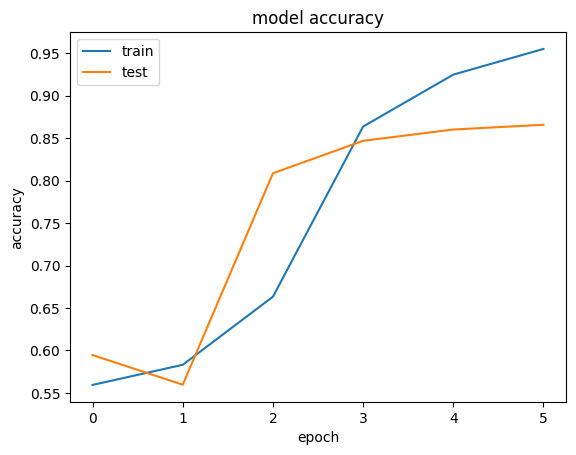

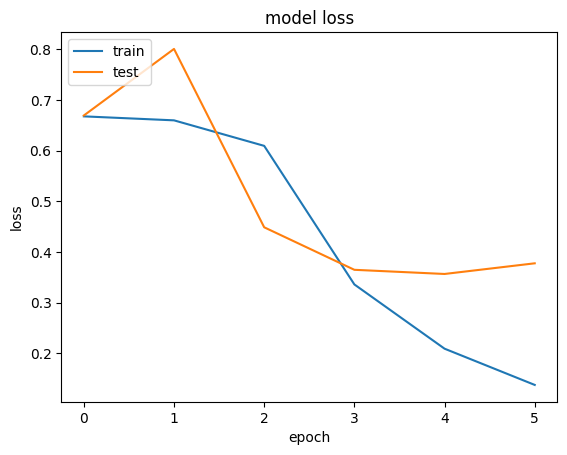

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history1.history['acc'])
plt.plot(lstm_model_history1.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history1.history['loss'])
plt.plot(lstm_model_history1.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
lstm_model.save(f"./l1_lstm_own_weights.3{round(score[1], 3)}.h5", save_format='h5')

In [ ]:
from tensorflow.keras.layers import LSTM, Dropout, Dense, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a new simple LSTM model with a slightly higher dropout rate
lstm_model_lr_higher_dropout = Sequential()

# Re-using existing embedding_layer setup
# vocab_length and embedding_matrix are available from previous cells
# maxlen is available from previous cells
embedding_layer = Embedding(
    vocab_length, 100, weights=[embedding_matrix], trainable=False
)

lstm_model_lr_higher_dropout.add(embedding_layer)
lstm_model_lr_higher_dropout.add(LSTM(128))
lstm_model_lr_higher_dropout.add(Dropout(0.3)) # Increased dropout rate
lstm_model_lr_higher_dropout.add(Dense(1, activation='sigmoid'))

# Compile the model with the same optimizer and loss
lstm_model_lr_higher_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(lstm_model_lr_higher_dropout.summary())

# Define the same callbacks for early stopping and learning rate reduction
early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
lr_scheduler_tuned = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

# Train the new model with callbacks
lstm_model_history_higher_dropout = lstm_model_lr_higher_dropout.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stop_tuned, lr_scheduler_tuned]
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - acc: 0.7558 - loss: 0.4997 - val_acc: 0.7513 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8166 - loss: 0.4189 - val_acc: 0.8098 - val_loss: 0.4041 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8403 - loss: 0.3728 - val_acc: 0.8495 - val_loss: 0.3530 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8558 - loss: 0.3418 - val_acc: 0.8625 - val_loss: 0.3352 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - acc: 0.8649 - loss: 0.3226 - val_acc: 0.8599 - val_loss: 0.3216 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8738 - loss: 0.3051 - val_acc: 0.8706 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8780 - loss: 0.2949 - val_acc: 0.8698 - val_loss: 0.3161 - learning_rate: 0

In [ ]:
score = lstm_model_lr_higher_dropout.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8667 - loss: 0.3087


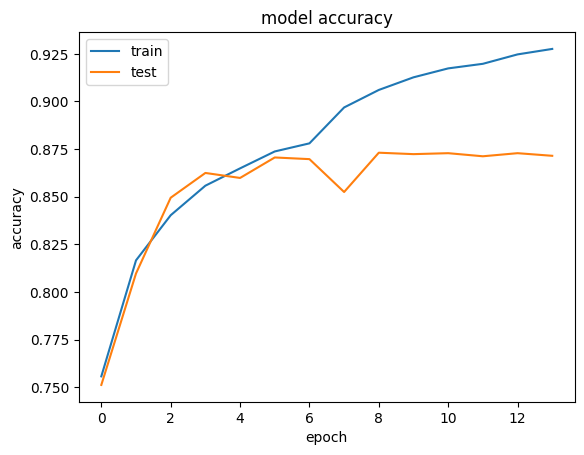

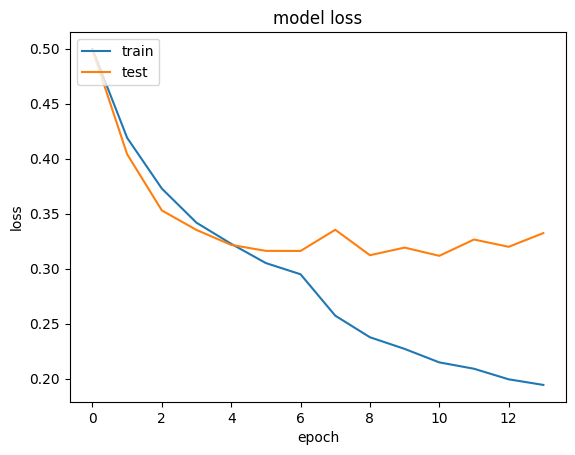

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history_higher_dropout.history['acc'])
plt.plot(lstm_model_history_higher_dropout.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history_higher_dropout.history['loss'])
plt.plot(lstm_model_history_higher_dropout.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
lstm_model_lr_higher_dropout.save(f"./l1_lstm_model_higher_drp_lrshed{round(score[1], 3)}.h5", save_format='h5')

In [ ]:
lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=200 , trainable=False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1, activation='sigmoid'))
print(lstm_model.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
# Model Training
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
lstm_model_history = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.7519 - loss: 0.5072 - val_acc: 0.7582 - val_loss: 0.5028
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8069 - loss: 0.4344 - val_acc: 0.8304 - val_loss: 0.3869
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8354 - loss: 0.3776 - val_acc: 0.8429 - val_loss: 0.4071
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8472 - loss: 0.3563 - val_acc: 0.8586 - val_loss: 0.3380
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8583 - loss: 0.3334 - val_acc: 0.8564 - val_loss: 0.3369
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8686 - loss: 0.3136 - val_acc: 0.8625 - val_loss: 0.3205


In [ ]:
# Predictions on the Test Set

score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8637 - loss: 0.3227


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.32265302538871765
Test Accuracy: 0.8636999726295471


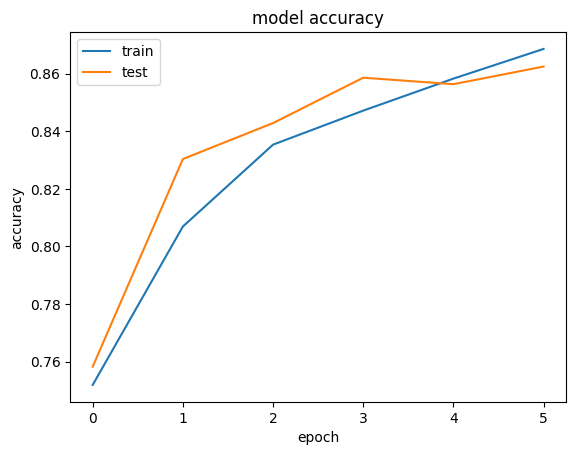

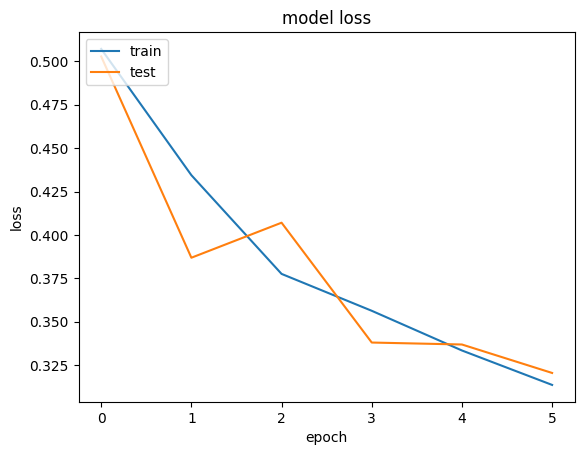

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
# Saving the model as a h5 file for possible use later

lstm_model.save(f"./l1_lstm_model_glove_emb{round(score[1], 3)}.h5", save_format='h5')

In [ ]:
lstm_model_lr = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=200 , trainable=False)

lstm_model_lr.add(embedding_layer)
lstm_model_lr.add(LSTM(128))
lstm_model_lr.add(Dropout(0.2))

lstm_model_lr.add(Dense(1, activation='sigmoid'))
print(lstm_model_lr.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [ ]:
lstm_model_lr.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
lstm_model_history = lstm_model_lr.fit(X_train, y_train, batch_size=128, epochs=15, verbose=1, validation_split=0.2,callbacks=[early_stop, lr_scheduler])

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.7436 - loss: 0.5198 - val_acc: 0.8098 - val_loss: 0.4363 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8155 - loss: 0.4191 - val_acc: 0.8190 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8372 - loss: 0.3740 - val_acc: 0.8512 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.8521 - loss: 0.3461 - val_acc: 0.8597 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8654 - loss: 0.3254 - val_acc: 0.8648 - val_loss: 0.3206 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8741 - loss: 0.3068 - val_acc: 0.8546 - val_loss: 0.3388 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8878 - loss: 0.2744 - val_acc: 0.8662 - val_loss: 0.3205 - learning_rate: 5.0000

In [ ]:
score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8637 - loss: 0.3227


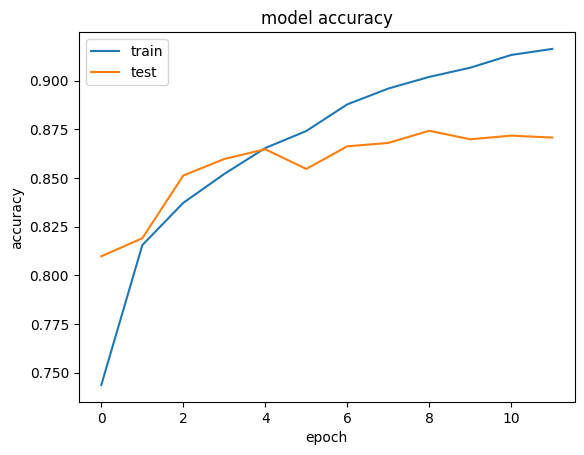

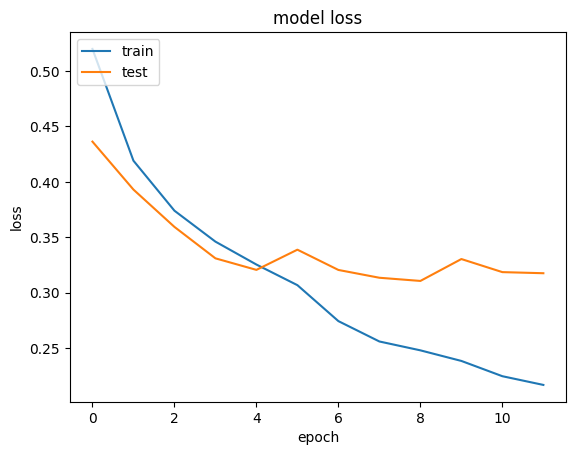

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

# Making Predictions on Live IMDb data

In [ ]:
!ls # lists files in working directory

 a1_IMDB_Dataset.csv
 a2_glove.6B.100d.txt
 a3_IMDb_Unseen_Reviews.csv
 ann_simple0.751.h5
'c1_cnn_model_acc_flatten()_0.807.h5'
'c1_cnn_model_acc_flatten()_droput.30.797.h5'
 c1_cnn_model_acc_globalmax_droput.3_earlystop0.495.h5
 l1_lstm_model_glove_emb0.864.h5
 l1_lstm_model_higher_drp_lrshed0.867.h5
 l1_lstm_own_weights.30.865.h5
 sample_data


In [ ]:
# # Load previously trained LSTM Model

# from keras.models import load_model

# model_path ='./c1_lstm_model_acc_0.856.h5'
# pretrained_lstm_model = load_model(model_path)

# # summarize model.
# pretrained_lstm_model.summary()

In [ ]:
# Load sample IMDb reviews csv, having ~6 movie reviews, along with their IMDb rating

sample_reviews = pd.read_csv("a3_IMDb_Unseen_Reviews.csv")

sample_reviews.head(6)

,Unnamed: 0,Movie,Review Text,IMDb Rating
0,0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9
1,1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10
2,2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3
3,3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1
4,4,Eternals,Amazing visuals and philosophical concepts!\n\...,10
5,5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3


In [ ]:
# Preprocess review text with earlier defined preprocess_text function

unseen_reviews = sample_reviews['Review Text']

unseen_processed = []
for review in unseen_reviews:
  review = preprocess_text(review)
  unseen_processed.append(review)

In [ ]:
# Tokenising instance with earlier trained tokeniser
unseen_tokenized = word_tokenizer.texts_to_sequences(unseen_processed)

# Pooling instance to have maxlength of 100 tokens
unseen_padded = pad_sequences(unseen_tokenized, padding='post', maxlen=maxlen)

In [ ]:
# Passing tokenised instance to the LSTM model for predictions
unseen_sentiments = lstm_model.predict(unseen_padded)

unseen_sentiments

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


array([[0.8930655 ],
       [0.9860007 ],
       [0.03817071],
       [0.42319447],
       [0.97816133],
       [0.01744015]], dtype=float32)

In [ ]:
# Writing model output file back to Google Drive

sample_reviews['Predicted Sentiments'] = np.round(unseen_sentiments*10,1)

df_prediction_sentiments = pd.DataFrame(sample_reviews['Predicted Sentiments'], columns = ['Predicted Sentiments'])
df_movie                 = pd.DataFrame(sample_reviews['Movie'], columns = ['Movie'])
df_review_text           = pd.DataFrame(sample_reviews['Review Text'], columns = ['Review Text'])
df_imdb_rating           = pd.DataFrame(sample_reviews['IMDb Rating'], columns = ['IMDb Rating'])


dfx=pd.concat([df_movie, df_review_text, df_imdb_rating, df_prediction_sentiments], axis=1)

dfx.to_csv("./c2_IMDb_Unseen_Predictions.csv", sep=',', encoding='UTF-8')

dfx.head(6)

,Movie,Review Text,IMDb Rating,Predicted Sentiments
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,8.9
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,9.9
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,0.4
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,4.2
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.8
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,0.2


### Making Predictions for Other Models

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create a padded sequence for SNN and CNN models with maxlen=100
unseen_padded_snn_cnn = pad_sequences(unseen_tokenized, padding='post', maxlen=100)

print(f"Shape of unseen_padded for SNN/CNN (maxlen=100): {unseen_padded_snn_cnn.shape}")
print(f"Shape of unseen_padded for LSTM/BiLSTM (maxlen=200): {unseen_padded.shape}")

Shape of unseen_padded for SNN/CNN (maxlen=100): (6, 100)
Shape of unseen_padded for LSTM/BiLSTM (maxlen=200): (6, 200)


#### Simple Neural Network (SNN) Predictions

In [ ]:
# Passing tokenised instance to the SNN model for predictions
unseen_sentiments_snn = snn_model.predict(unseen_padded_snn_cnn)

sample_reviews['Predicted Sentiments (SNN)'] = np.round(unseen_sentiments_snn * 10, 1)

dfx_snn = pd.concat([sample_reviews['Movie'], sample_reviews['Review Text'], sample_reviews['IMDb Rating'], sample_reviews['Predicted Sentiments (SNN)']], axis=1)

dfx_snn.to_csv("./c2_IMDb_Unseen_Predictions_SNN.csv", sep=',', encoding='UTF-8')

display(dfx_snn.head(6))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


,Movie,Review Text,IMDb Rating,Predicted Sentiments (SNN)
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,5.8
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,8.5
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,0.9
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,7.0
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.3
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,8.2


#### Convolutional Neural Network (CNN) Predictions

In [ ]:
# Passing tokenised instance to the CNN model for predictions
unseen_sentiments_cnn = cnn_model.predict(unseen_padded_snn_cnn)

sample_reviews['Predicted Sentiments (CNN)'] = np.round(unseen_sentiments_cnn * 10, 1)

dfx_cnn = pd.concat([sample_reviews['Movie'], sample_reviews['Review Text'], sample_reviews['IMDb Rating'], sample_reviews['Predicted Sentiments (CNN)']], axis=1)

dfx_cnn.to_csv("./c2_IMDb_Unseen_Predictions_CNN.csv", sep=',', encoding='UTF-8')

display(dfx_cnn.head(6))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


,Movie,Review Text,IMDb Rating,Predicted Sentiments (CNN)
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,4.7
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,6.2
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,4.7
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,5.6
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,6.4
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,5.6


#### Long Short-Term Memory (LSTM) Predictions

In [ ]:
# Passing tokenised instance to the LSTM model for predictions
unseen_sentiments_lstm = lstm_model.predict(unseen_padded)

sample_reviews['Predicted Sentiments (LSTM)'] = np.round(unseen_sentiments_lstm * 10, 1)

dfx_lstm = pd.concat([sample_reviews['Movie'], sample_reviews['Review Text'], sample_reviews['IMDb Rating'], sample_reviews['Predicted Sentiments (LSTM)']], axis=1)

dfx_lstm.to_csv("./c2_IMDb_Unseen_Predictions_LSTM.csv", sep=',', encoding='UTF-8')

display(dfx_lstm.head(6))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,Movie,Review Text,IMDb Rating,Predicted Sentiments (LSTM)
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,8.9
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,9.9
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,0.4
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,4.2
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.8
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,0.2


#### Bidirectional Long Short-Term Memory (BiLSTM) Predictions

In [ ]:
# Passing tokenised instance to the BiLSTM model for predictions
unseen_sentiments_bilstm = bilstm_model.predict(unseen_padded)

sample_reviews['Predicted Sentiments (BiLSTM)'] = np.round(unseen_sentiments_bilstm * 10, 1)

dfx_bilstm = pd.concat([sample_reviews['Movie'], sample_reviews['Review Text'], sample_reviews['IMDb Rating'], sample_reviews['Predicted Sentiments (BiLSTM)']], axis=1)

dfx_bilstm.to_csv("./c2_IMDb_Unseen_Predictions_BiLSTM.csv", sep=',', encoding='UTF-8')

display(dfx_bilstm.head(6))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


,Movie,Review Text,IMDb Rating,Predicted Sentiments (BiLSTM)
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,9.5
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,10.0
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,0.3
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,6.6
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.9
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,0.5


In [ ]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential()

embedding_layer = Embedding(
    vocab_length,
    100,
    weights=[embedding_matrix],
    input_length=maxlen,
    trainable=False
)

bilstm_model.add(embedding_layer)

bilstm_model.add(
    Bidirectional(LSTM(128))
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(1, activation='sigmoid'))

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

In [ ]:
bilstm_model_history = bilstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7592 - loss: 0.4970 - val_accuracy: 0.8121 - val_loss: 0.4184
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8122 - loss: 0.4161 - val_accuracy: 0.8294 - val_loss: 0.3792
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8434 - loss: 0.3601 - val_accuracy: 0.8549 - val_loss: 0.3505
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8573 - loss: 0.3332 - val_accuracy: 0.8597 - val_loss: 0.3284
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8703 - loss: 0.3063 - val_accuracy: 0.8597 - val_loss: 0.3246
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8782 - loss: 0.2912 - val_accuracy: 0.8624 - val_loss: 0.3166


In [ ]:
score = bilstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8583 - loss: 0.3229


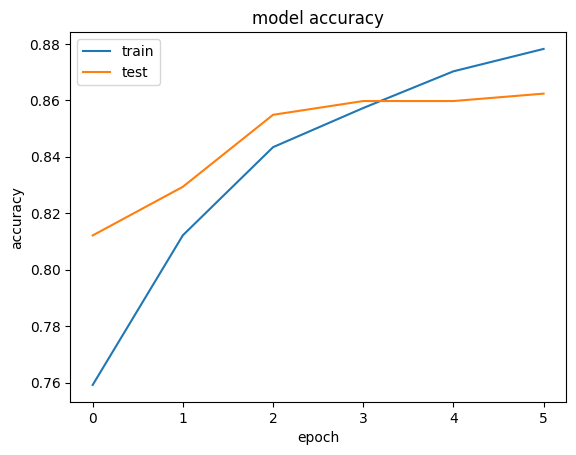

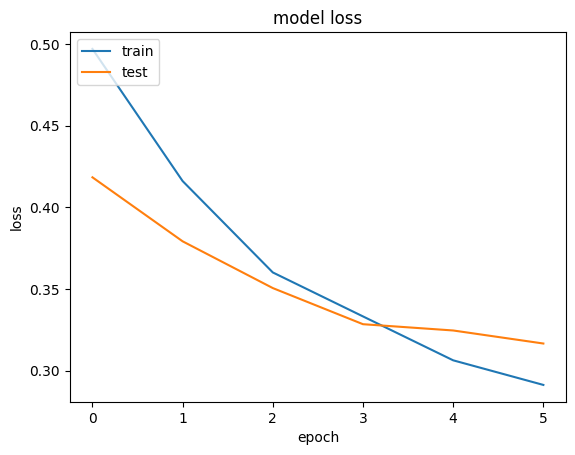

In [ ]:
import matplotlib.pyplot as plt

plt.plot(bilstm_model_history.history['accuracy'])
plt.plot(bilstm_model_history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(bilstm_model_history.history['loss'])
plt.plot(bilstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# Define the new BiLSTM model
bilstm_model_es = Sequential()

embedding_layer = Embedding(
    vocab_length,
    100,
    weights=[embedding_matrix],
    input_length=maxlen,
    trainable=False
)

bilstm_model_es.add(embedding_layer)
bilstm_model_es.add(Bidirectional(LSTM(128)))
bilstm_model_es.add(Dropout(0.2))
bilstm_model_es.add(Dense(1, activation='sigmoid'))

# Compile the model
bilstm_model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(bilstm_model_es.summary())

# Define EarlyStopping callback
early_stop_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train the new BiLSTM model with 15 epochs and EarlyStopping
bilstm_model_history_es = bilstm_model_es.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stop_bilstm]
)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7654 - loss: 0.4823 - val_accuracy: 0.8029 - val_loss: 0.4386
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8210 - loss: 0.3986 - val_accuracy: 0.8360 - val_loss: 0.3854
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8416 - loss: 0.3611 - val_accuracy: 0.8421 - val_loss: 0.3696
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8611 - loss: 0.3265 - val_accuracy: 0.8496 - val_loss: 0.3500
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8670 - loss: 0.3128 - val_accuracy: 0.8464 - val_loss: 0.3407
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8806 - loss: 0.2873 - val_accuracy: 0.8493 - val_loss: 0.3464
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8926 - loss: 0.2632 - val_accuracy: 0.8708 - val_loss: 0.3141
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9014 - loss: 0.2433 - val

In [ ]:
score = bilstm_model_es.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8662 - loss: 0.3158


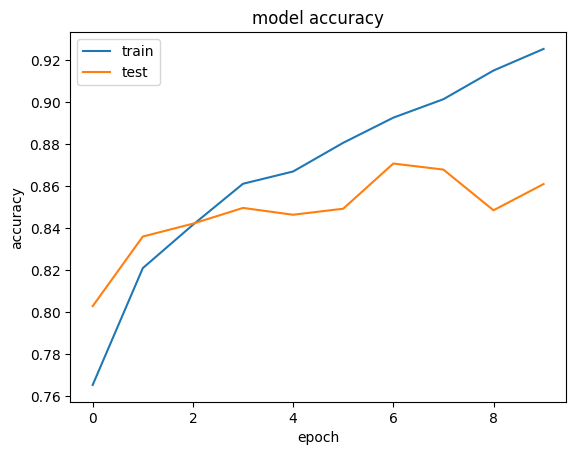

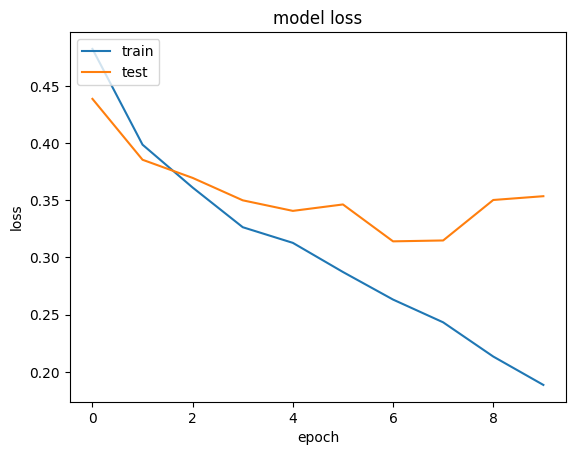

In [ ]:
import matplotlib.pyplot as plt

plt.plot(bilstm_model_history_es.history['accuracy'])
plt.plot(bilstm_model_history_es.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(bilstm_model_history_es.history['loss'])
plt.plot(bilstm_model_history_es.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- Evaluating {model_name} ---")

    # Predict probabilities on the test set
    y_pred_proba = model.predict(X_test)

    # Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_binary)
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_binary)
    print("Confusion Matrix:")
    print(cm)

    # Extract TP, FP, TN, FN
    tn, fp, fn, tp = cm.ravel()
    print(f"True Positives (TP): {tp}")
    print(f"False Positives (FP): {fp}")
    print(f"True Negatives (TN): {tn}")
    print(f"False Negatives (FN): {fn}")

# Evaluate Simple Neural Network (SNN) model
evaluate_model(snn_model, X_test, y_test, "Simple Neural Network")

# Evaluate Convolutional Neural Network (CNN) model
evaluate_model(cnn_model, X_test, y_test, "Convolutional Neural Network")

# Evaluate Long Short-Term Memory (LSTM) model
evaluate_model(lstm_model, X_test, y_test, "Long Short-Term Memory (LSTM)")


# Evaluate Bidirectional LSTM (BiLSTM) model, if it was intended to be evaluated as a primary model.
evaluate_model(bilstm_model, X_test, y_test, "Bidirectional Long Short-Term Memory (BiLSTM)")


--- Evaluating Simple Neural Network ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.7514
Precision: 0.7484
Recall: 0.7632
F1 Score: 0.7557
Confusion Matrix:
[[3668 1293]
 [1193 3846]]
True Positives (TP): 3846
False Positives (FP): 1293
True Negatives (TN): 3668
False Negatives (FN): 1193

--- Evaluating Convolutional Neural Network ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.5029
Precision: 0.5040
Recall: 0.8587
F1 Score: 0.6352
Confusion Matrix:
[[ 702 4259]
 [ 712 4327]]
True Positives (TP): 4327
False Positives (FP): 4259
True Negatives (TN): 702
False Negatives (FN): 712

--- Evaluating Long Short-Term Memory (LSTM) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.8637
Precision: 0.8514
Recall: 0.8837
F1 Score: 0.8673
Confusion Matrix:
[[4184  777]
 [ 586 4453]]
True Positives (TP): 4453
False Positives (FP): 777
True Negatives (TN): 4184
False Negatives (FN): 586

--- Evaluating Bidirectional Long Short-Term Memory (BiLSTM) ---
313/313 ━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


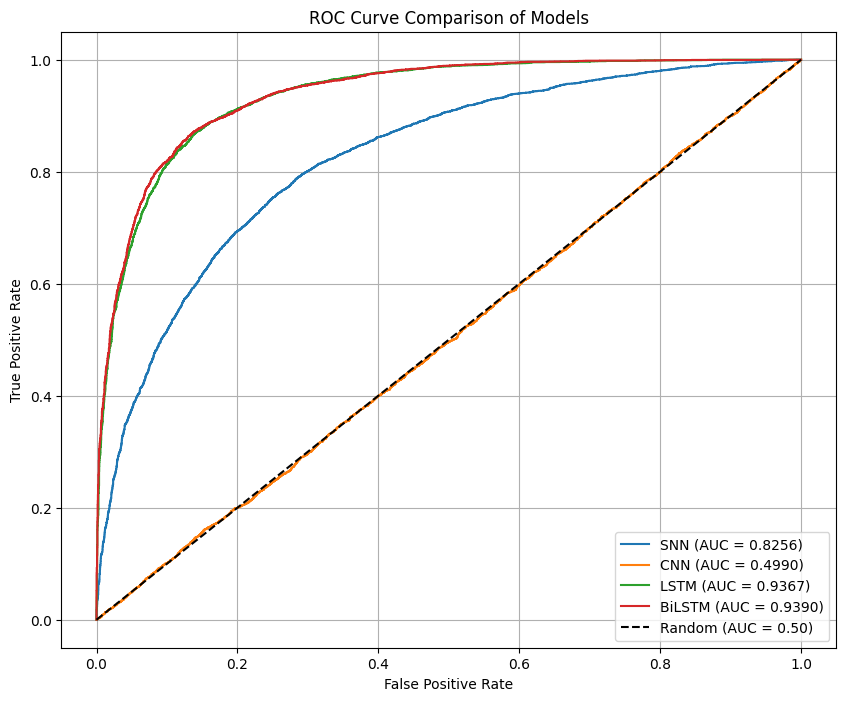

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# SNN Model
y_pred_proba_snn = snn_model.predict(X_test)
fpr_snn, tpr_snn, _ = roc_curve(y_test, y_pred_proba_snn)
auc_snn = roc_auc_score(y_test, y_pred_proba_snn)
plt.plot(fpr_snn, tpr_snn, label=f'SNN (AUC = {auc_snn:.4f})')

# CNN Model
y_pred_proba_cnn = cnn_model.predict(X_test)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_proba_cnn)
auc_cnn = roc_auc_score(y_test, y_pred_proba_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {auc_cnn:.4f})')

# LSTM Model
y_pred_proba_lstm = lstm_model.predict(X_test)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_proba_lstm)
auc_lstm = roc_auc_score(y_test, y_pred_proba_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.4f})')

# BiLSTM Model
y_pred_proba_bilstm = bilstm_model.predict(X_test)
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_test, y_pred_proba_bilstm)
auc_bilstm = roc_auc_score(y_test, y_pred_proba_bilstm)
plt.plot(fpr_bilstm, tpr_bilstm, label=f'BiLSTM (AUC = {auc_bilstm:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

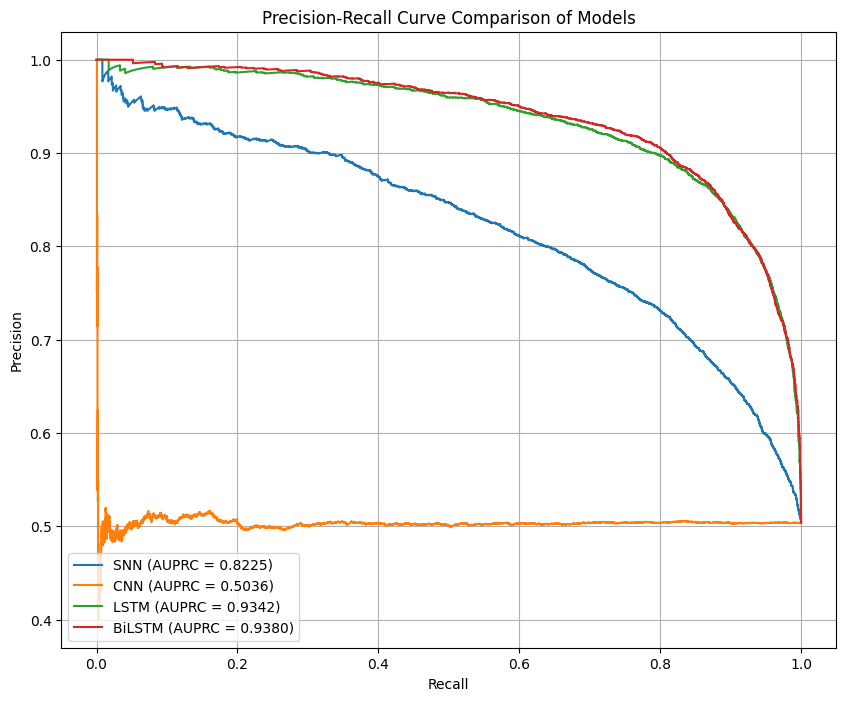

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# SNN Model
# y_pred_proba_snn was already calculated for ROC curve
precision_snn, recall_snn, _ = precision_recall_curve(y_test, y_pred_proba_snn)
auc_pr_snn = auc(recall_snn, precision_snn)
plt.plot(recall_snn, precision_snn, label=f'SNN (AUPRC = {auc_pr_snn:.4f})')

# CNN Model
# y_pred_proba_cnn was already calculated for ROC curve
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_pred_proba_cnn)
auc_pr_cnn = auc(recall_cnn, precision_cnn)
plt.plot(recall_cnn, precision_cnn, label=f'CNN (AUPRC = {auc_pr_cnn:.4f})')

# LSTM Model
# y_pred_proba_lstm was already calculated for ROC curve
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test, y_pred_proba_lstm)
auc_pr_lstm = auc(recall_lstm, precision_lstm)
plt.plot(recall_lstm, precision_lstm, label=f'LSTM (AUPRC = {auc_pr_lstm:.4f})')

# BiLSTM Model
# y_pred_proba_bilstm was already calculated for ROC curve
precision_bilstm, recall_bilstm, _ = precision_recall_curve(y_test, y_pred_proba_bilstm)
auc_pr_bilstm = auc(recall_bilstm, precision_bilstm)
plt.plot(recall_bilstm, precision_bilstm, label=f'BiLSTM (AUPRC = {auc_pr_bilstm:.4f})')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison of Models')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()